# Concentration Gradient in a Catalyst Particle

When a reaction occurs inside a porous particle, the reactant concentration may be lower in the interior than at the surface. This idea is formalized with the Thiele modulus, introduced to relate catalytic activity and particle size, and with criteria such as Weisz-Prater for detecting diffusional limitations {cite:p}`thiele1939catalytic_activity_particle_size,weisz1954experimental_catalysis`.

For a first-order reaction in a spherical particle, a useful scale is:

$$
\phi = R_p\sqrt{\frac{k}{D_e}}
$$

The figure compares external transfer, internal diffusion, and kinetics. The vertical axis now adjusts automatically to the useful range of the profiles, and center and surface are marked so the radial progression is easier to read.

```{admonition} What to modify
:class: dropdown
Change `kf`, `De`, or `k` in the `scenarios` list. If $D_e$ decreases or $k$ increases, $\phi$ increases and the internal profile falls more strongly.
```


Scenario summary
Fast transfer: phi=0.40, eta=0.99, C_surface/C_bulk=1.00
Low internal diffusion: phi=0.90, eta=0.95, C_surface/C_bulk=1.00
Slow external film: phi=0.40, eta=0.99, C_surface/C_bulk=0.98
Fast kinetics: phi=0.76, eta=0.96, C_surface/C_bulk=0.99


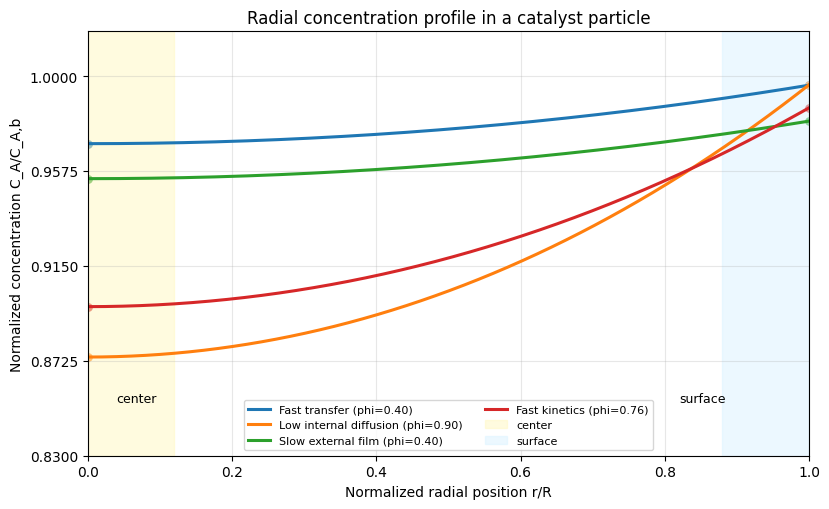

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
R_particle = 1.5e-3   # m
C_bulk = 1.0          # mol/L, used as reference
scenarios = [('Fast transfer', 0.03, 3.5e-06, 0.25), ('Low internal diffusion', 0.03, 7e-07, 0.25), ('Slow external film', 0.006, 3.5e-06, 0.25), ('Fast kinetics', 0.03, 3.5e-06, 0.9)]


def effectiveness_factor(phi):
    if phi < 1e-6:
        return 1.0
    return 3 / phi**2 * (phi / np.tanh(phi) - 1)


def profile(r_over_R, kf, De, k):
    phi = R_particle * np.sqrt(k / De)
    eta = effectiveness_factor(phi)
    C_surface = C_bulk / (1 + eta * k * R_particle / (3 * kf))
    r_safe = np.maximum(r_over_R, 1e-6)
    internal = np.sinh(phi * r_safe) / (r_safe * np.sinh(phi)) if phi > 1e-6 else np.ones_like(r_safe)
    internal[0] = phi / np.sinh(phi) if phi > 1e-6 else 1.0
    return C_surface * internal / C_bulk, phi, eta, C_surface / C_bulk


r = np.linspace(0, 1, 250)
profiles = []
print("Scenario summary")
for name, kf, De, k in scenarios:
    C, phi, eta, Cs = profile(r, kf, De, k)
    profiles.append((name, C, phi, eta, Cs))
    print(f"{name}: phi={phi:.2f}, eta={eta:.2f}, C_surface/C_bulk={Cs:.2f}")

y_min = max(0.0, min(C.min() for _, C, _, _, _ in profiles) - 0.04)
y_max = 1.02

fig, ax = plt.subplots(figsize=(8.4, 5.2))
for name, C, phi, eta, Cs in profiles:
    ax.plot(r, C, linewidth=2.2, label=f"{name} (phi={phi:.2f})")
    ax.scatter([0, 1], [C[0], C[-1]], s=28)

ax.axvspan(0, 0.12, color="#fff8c5", alpha=0.55, label="center")
ax.axvspan(0.88, 1, color="#ddf4ff", alpha=0.55, label="surface")
ax.set_xlim(0, 1)
ax.set_ylim(y_min, y_max)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(round(y_min, 2), 1.0, 5))
ax.set_xlabel("Normalized radial position r/R")
ax.set_ylabel("Normalized concentration C_A/C_A,b")
ax.set_title("Radial concentration profile in a catalyst particle")
ax.grid(alpha=0.3)
ax.annotate("center", xy=(0.04, y_min + 0.02), fontsize=9)
ax.annotate("surface", xy=(0.82, y_min + 0.02), fontsize=9)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Interpretation

If internal diffusion is slow or kinetics are fast, a strong gradient appears inside the particle. If external transfer is slow, even the surface concentration drops below the bulk-fluid concentration.

```{admonition} Guided reading
:class: dropdown
Compare the marked points at $r/R=0$ and $r/R=1$. The separation between them summarizes internal loss; the surface drop below $1$ summarizes external resistance.
```
